<a href="https://colab.research.google.com/github/SakshyamAryal077/BASELINE-MODEL-ECG/blob/main/ImplementationCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Imports.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Add

from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation,
    MaxPooling1D, Concatenate
)
from tensorflow.keras.models import Model


In [ ]:
import numpy as np

X_train = np.load("X_train_smote.npy")
y_train = np.load("y_train_smote.npy")

X_test = np.load("X_testsmall.npy")
y_test = np.load("y_testsmall.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (108400, 360)
y_train shape: (108400,)
X_test shape: (6753, 360, 1)
y_test shape: (6753,)


In [ ]:
if len(X_train.shape) == 2:
    X_train = np.expand_dims(X_train, axis=-1)

if len(X_test.shape) == 2:
    X_test = np.expand_dims(X_test, axis=-1)

print("After channel add:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


After channel add:
X_train shape: (108400, 360, 1)
X_test shape: (6753, 360, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = 5

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)


y_train_cat shape: (108400, 5)
y_test_cat shape: (6753, 5)


In [ ]:
print("Final training input shape:", X_train.shape)
print("Final training label shape:", y_train_cat.shape)
print("Final testing input shape:", X_test.shape)
print("Final testing label shape:", y_test_cat.shape)


Final training input shape: (108400, 360, 1)
Final training label shape: (108400, 5)
Final testing input shape: (6753, 360, 1)
Final testing label shape: (6753, 5)


### Step 1 - Stem Block (Changing for Experimentation)

In [ ]:
def stem_block(x, filters=32, kernel_size=7):
    x = Conv1D(filters=filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=2)(x)
    return x


Multi-scale block

In [ ]:
def multiscale_block(x, filters=32):
    branch1 = Conv1D(filters=filters, kernel_size=3, padding='same')(x)
    branch1 = BatchNormalization()(branch1)
    branch1 = Activation('relu')(branch1)

    branch2 = Conv1D(filters=filters, kernel_size=5, padding='same')(x)
    branch2 = BatchNormalization()(branch2)
    branch2 = Activation('relu')(branch2)

    branch3 = Conv1D(filters=filters, kernel_size=7, padding='same')(x)
    branch3 = BatchNormalization()(branch3)
    branch3 = Activation('relu')(branch3)

    x = Concatenate()([branch1, branch2, branch3])
    return x


 Test a mini model with just these blocks

In [ ]:
input_shape = (360, 1)   # change if your beat length is different

inputs = Input(shape=input_shape)

x = stem_block(inputs, filters=32, kernel_size=7)
x = multiscale_block(x, filters=32)

model = Model(inputs, x)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 360, 32)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 360, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 180, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 180, 32)   │      3,104 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 180, 32)   │      5,152 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 180, 32)   │      7,200 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 180, 96)   │          0 │ activation_1[0][… │
│ (Concatenate)       │                   │            │ activation_2[0][… │
│                     │                   │            │ activation_3[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,224 (63.38 KB)

 Trainable params: 15,968 (62.38 KB)

 Non-trainable params: 256 (1.00 KB)

Residual Blocks

In [ ]:
def residual_block(x, filters=96, kernel_size=3):
    shortcut = x

    x = Conv1D(filters=filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters=filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)

    return x


Test model with residual block added

In [ ]:
input_shape = (360, 1)

inputs = Input(shape=input_shape)

x = stem_block(inputs, filters=32, kernel_size=7)
x = multiscale_block(x, filters=32)
x = residual_block(x, filters=96, kernel_size=3)

model = Model(inputs, x)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 360, 32)   │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 180, 32)   │          0 │ activation_4[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 180, 32)   │      3,104 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 180, 32)   │      5,152 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 180, 32)   │      7,200 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 180, 96)   │          0 │ activation_5[0][… │
│ (Concatenate)       │                   │            │ activation_6[0][… │
│                     │                   │            │ activation_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 180, 96)   │     27,744 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 96)   │        384 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 180, 96)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 72,480 (283.12 KB)

 Trainable params: 71,840 (280.62 KB)

 Non-trainable params: 640 (2.50 KB)

SE attention block code

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Reshape, Multiply


In [ ]:
def se_block(x, reduction=16):
    filters = x.shape[-1]

    se = GlobalAveragePooling1D()(x)
    se = Dense(filters // reduction, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1, filters))(se)

    x = Multiply()([x, se])
    return x


In [ ]:
input_shape = (360, 1)

inputs = Input(shape=input_shape)

x = stem_block(inputs, filters=32, kernel_size=7)
x = multiscale_block(x, filters=32)
x = residual_block(x, filters=96, kernel_size=3)
x = se_block(x, reduction=16)

model = Model(inputs, x)
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 360, 32)   │        256 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 180, 32)   │          0 │ activation_10[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 180, 32)   │      5,152 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 180, 32)   │      7,200 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 180, 96)   │          0 │ activation_11[0]… │
│ (Concatenate)       │                   │            │ activation_12[0]… │
│                     │                   │            │ activation_13[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 180, 96)   │     27,744 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 96)   │        384 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 180, 96)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 73,734 (288.02 KB)

 Trainable params: 73,094 (285.52 KB)

 Non-trainable params: 640 (2.50 KB)

Add one more residual refinement block

In [ ]:
input_shape = (360, 1)

inputs = Input(shape=input_shape)

x = stem_block(inputs, filters=32, kernel_size=7)
x = multiscale_block(x, filters=32)
x = residual_block(x, filters=96, kernel_size=3)
x = se_block(x, reduction=16)
x = residual_block(x, filters=96, kernel_size=3)

model = Model(inputs, x)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 360, 32)   │        256 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 180, 32)   │          0 │ activation_16[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 180, 32)   │      5,152 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 180, 32)   │      7,200 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 180, 96)   │          0 │ activation_17[0]… │
│ (Concatenate)       │                   │            │ activation_18[0]… │
│                     │                   │            │ activation_19[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 180, 96)   │     27,744 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 96)   │        384 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 180, 96)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 129,990 (507.77 KB)

 Trainable params: 128,966 (503.77 KB)

 Non-trainable params: 1,024 (4.00 KB)

Add classifier head

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling1D, Dropout


In [ ]:
from tensorflow.keras.layers import Dense

num_classes = 5   # change if needed

inputs = Input(shape=(360, 1))

x = stem_block(inputs, filters=32, kernel_size=7)
x = multiscale_block(x, filters=32)
x = residual_block(x, filters=96, kernel_size=3)
x = se_block(x, reduction=16)
x = residual_block(x, filters=96, kernel_size=3)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 360, 32)   │        256 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 360, 32)   │        128 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 360, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 180, 32)   │          0 │ activation_24[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 180, 32)   │      3,104 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 180, 32)   │      5,152 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 180, 32)   │      7,200 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 32)   │        128 │ conv1d_27[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_26       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 180, 32)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 180, 96)   │          0 │ activation_25[0]… │
│ (Concatenate)       │                   │            │ activation_26[0]… │
│                     │                   │            │ activation_27[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 180, 96)   │     27,744 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 180, 96)   │        384 │ conv1d_28[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 180, 96)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                 

 Total params: 136,523 (533.29 KB)

 Trainable params: 135,499 (529.29 KB)

 Non-trainable params: 1,024 (4.00 KB)

One Hot Encoding before the Focal Loss.

In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = 5

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)


Focal loss Block

In [ ]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=1.0):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy

        return tf.reduce_sum(loss, axis=1)
    return loss_fn


Compiling

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=1.0),
    metrics=['accuracy']
)


Add Callbacks

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]


Train.

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step - accuracy: 0.8381 - loss: 0.2083 - val_accuracy: 0.8731 - val_loss: 0.1628 - learning_rate: 0.0010
Epoch 2/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9195 - loss: 0.0908 - val_accuracy: 0.9288 - val_loss: 0.0968 - learning_rate: 0.0010
Epoch 3/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9384 - loss: 0.0654 - val_accuracy: 0.8820 - val_loss: 0.1290 - learning_rate: 0.0010
Epoch 4/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9483 - loss: 0.0541 - val_accuracy: 0.9156 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 5/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9554 - loss: 0.0447 - val_accuracy: 0.9301 - val_loss: 0.0773 - learning_rate: 0.0010
Epoch 6/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9607 - loss: 0.0380 - val_accuracy: 0.9498 - val_loss: 0.0678 - learning_rate: 0.0010
Epoch 7/30
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.

In [ ]:
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)


212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = ['F', 'N', 'Q', 'S', 'V']

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           F       0.80      0.73      0.76        48
           N       0.98      0.97      0.97      5421
           Q       0.82      0.88      0.85       683
           S       0.85      0.72      0.78       167
           V       0.82      0.97      0.89       434

    accuracy                           0.95      6753
   macro avg       0.85      0.85      0.85      6753
weighted avg       0.95      0.95      0.95      6753

Confusion Matrix:
[[  35    8    0    0    5]
 [   7 5237  110   20   47]
 [   0   48  601    2   32]
 [   0   30    9  120    8]
 [   2    2    9    0  421]]


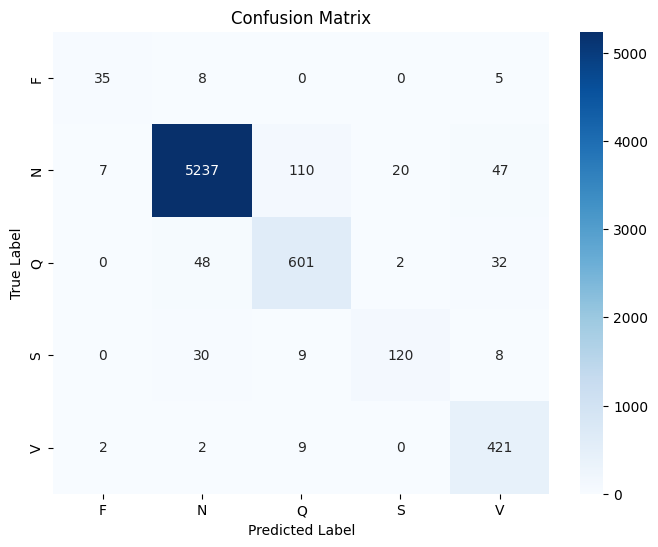

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


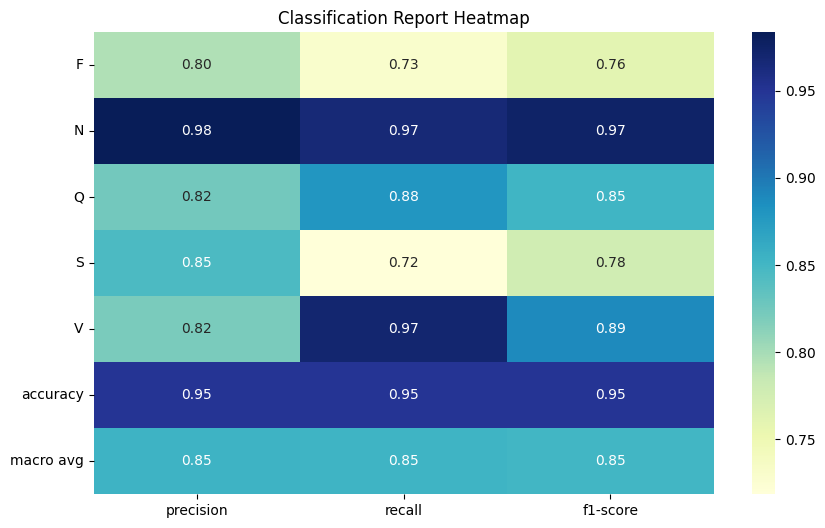

In [ ]:
import pandas as pd

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()


In [ ]:
model.save("version1_ecg_model.keras")


In [ ]:
model.save_weights("version1_weights.weights.h5")
